<a href="https://colab.research.google.com/github/kamil0sek1/kursAI/blob/main/wykresy_rozmyte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.9 MB/s eta 0:00:00


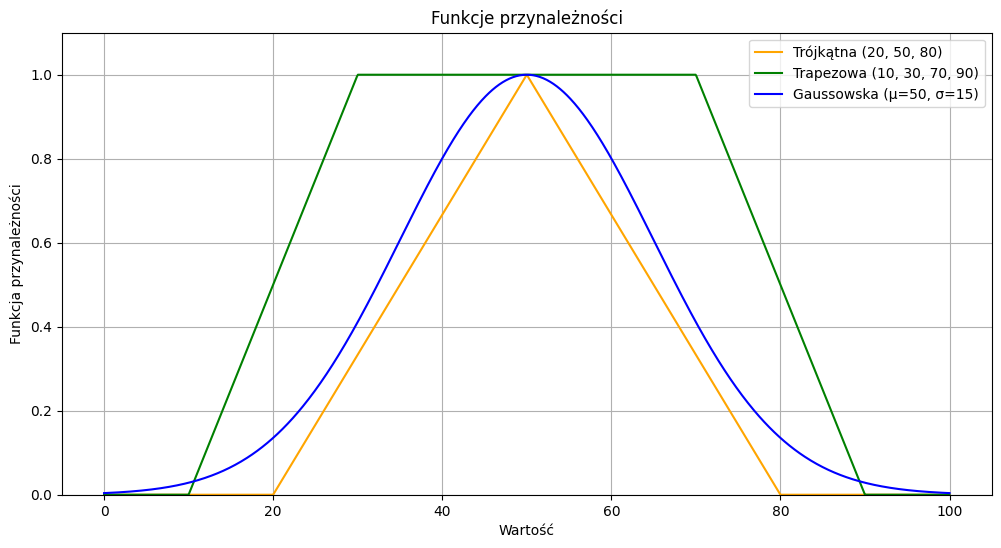

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz




x = np.linspace(0, 100, 1000)

trimf = fuzz.trimf(x, [20, 50, 80])
trapmf = fuzz.trapmf(x, [10, 30, 70, 90])
gaussmf = fuzz.gaussmf(x, mean=50, sigma=15)



plt.figure(figsize=(12, 6))
plt.plot(x, trimf, label='Trójkątna (20, 50, 80)', color='orange')
plt.plot(x, trapmf, label='Trapezowa (10, 30, 70, 90)', color='green')
plt.plot(x, gaussmf, label='Gaussowska (μ=50, σ=15)', color='blue')

plt.title("Funkcje przynależności")
plt.xlabel("Wartość")
plt.ylabel("Funkcja przynależności")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True)

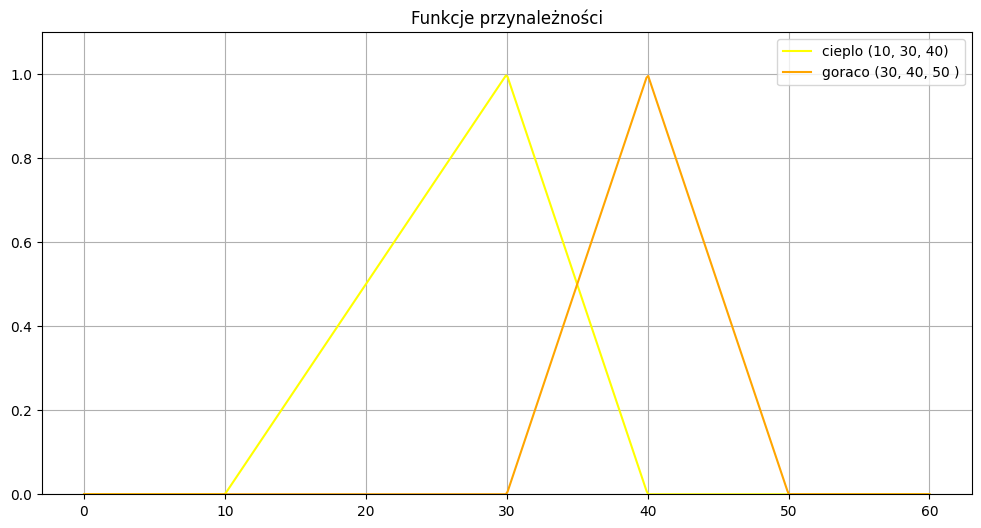

In [8]:
# Wygeneruj wykresy funkcji trójkątnych ciepło(10,30,40) i
# gorąco(30,40,50).

x = np.linspace(0, 60, 500)
cieplo =fuzz.trimf(x,[10,30,40])
goraco =fuzz.trimf(x,[30,40,50])


plt.figure(figsize=(12, 6))
plt.plot(x, cieplo, label='cieplo (10, 30, 40)', color='yellow')
plt.plot(x, goraco, label='goraco (30, 40, 50 )', color='orange')
plt.title("Funkcje przynależności")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True)

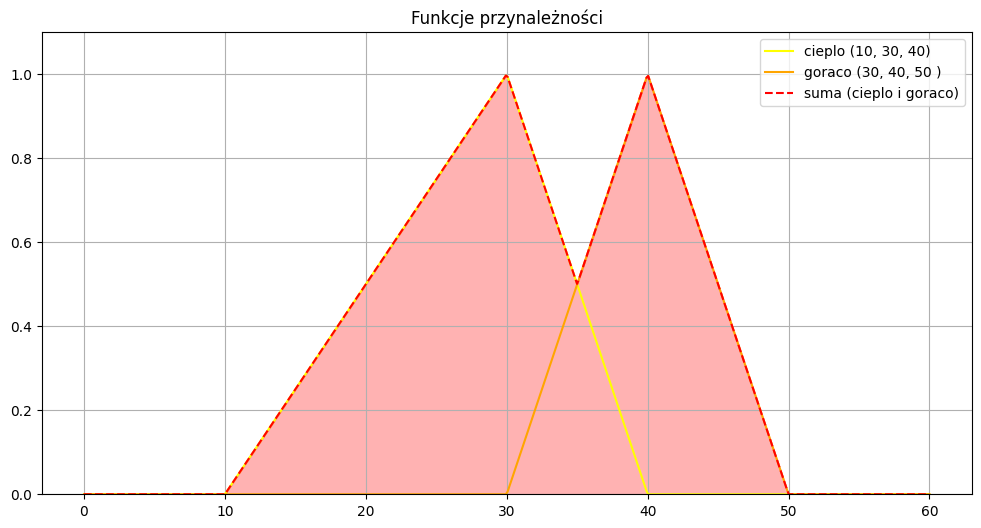

In [13]:
# Wygeneruj wykres przedstawiający sumę zbiorów ciepło i gorąco


x = np.linspace(0, 60, 500)
cieplo =fuzz.trimf(x,[10,30,40])
goraco =fuzz.trimf(x,[30,40,50])
suma = np.maximum(cieplo,goraco)

plt.figure(figsize=(12, 6))
plt.plot(x, cieplo, label='cieplo (10, 30, 40)', color='yellow')
plt.plot(x, goraco, label='goraco (30, 40, 50 )', color='orange')
plt.plot(x, suma, "--", label='suma (cieplo i goraco)', color='red')
plt.fill_between(x, suma, alpha=0.3, color="red")

plt.title("Funkcje przynależności")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True)


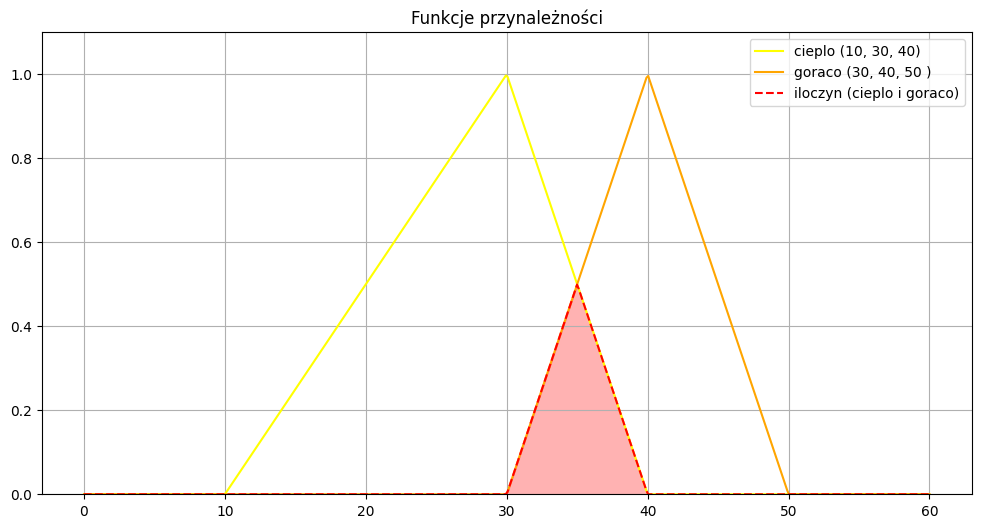

In [16]:
#Wygeneruj wykres przedstawiający iloczyn zbiorów ciepło i gorąco


x = np.linspace(0, 60, 500)
cieplo =fuzz.trimf(x,[10,30,40])
goraco =fuzz.trimf(x,[30,40,50])
iloczyn = np.minimum(cieplo,goraco)

plt.figure(figsize=(12, 6))
plt.plot(x, cieplo, label='cieplo (10, 30, 40)', color='yellow')
plt.plot(x, goraco, label='goraco (30, 40, 50 )', color='orange')
plt.plot(x, iloczyn, "--", label='iloczyn (cieplo i goraco)', color='red')
plt.fill_between(x, iloczyn, alpha=0.3, color="red")

plt.title("Funkcje przynależności")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True)

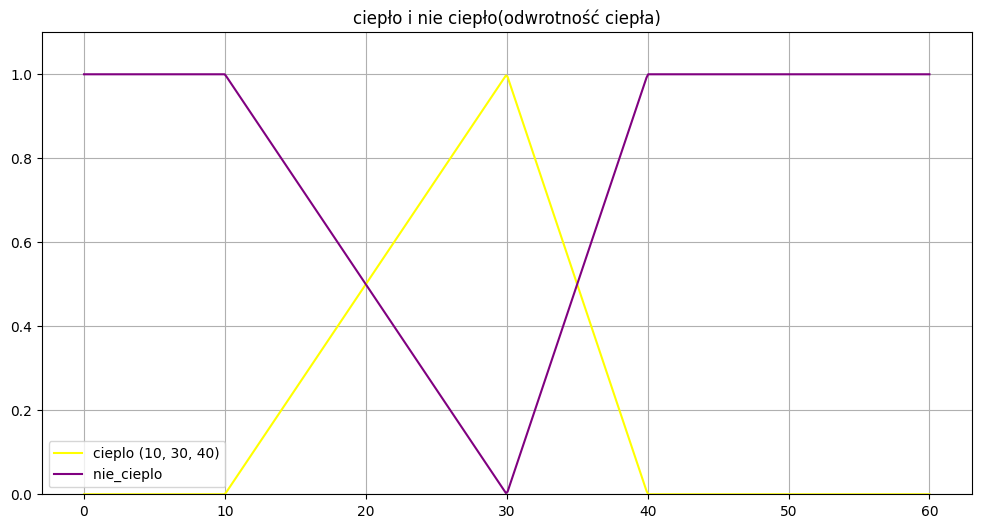

In [24]:
# 4.Wygeneruj wykres przedstawiający negację zbioru ciepło


x = np.linspace(0, 60, 500)
cieplo =fuzz.trimf(x,[10,30,40])

nie_cieplo = 1 - cieplo

plt.figure(figsize=(12, 6))
plt.plot(x, cieplo, label='cieplo (10, 30, 40)', color='yellow')
plt.plot(x, nie_cieplo, label='nie_cieplo ', color='purple')
plt.title("ciepło i nie ciepło(odwrotność ciepła)")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True)


<function matplotlib.pyplot.show(close=None, block=None)>

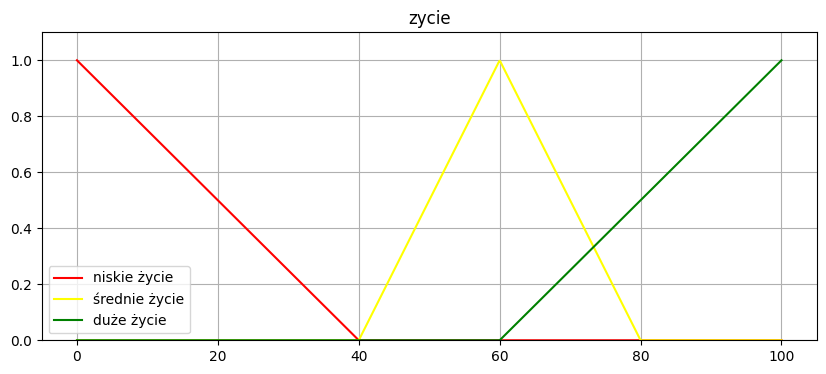

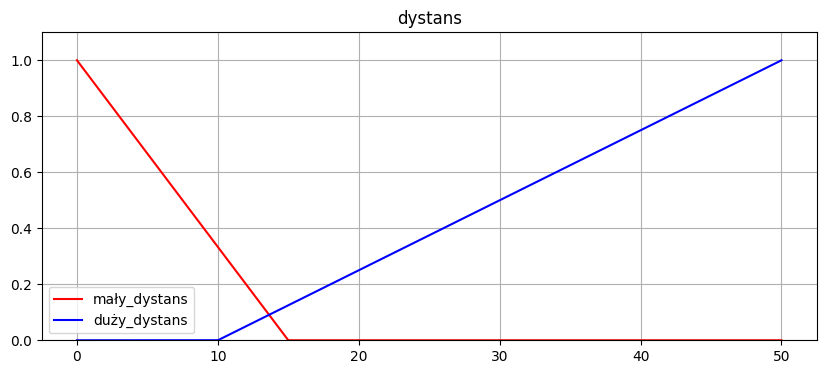

In [27]:
x_life = np.linspace(0, 100, 1000)
x_dystans = np.linspace(0, 50, 1000)
low_life = fuzz.trimf(x_life, [0, 0, 40])
medium_life = fuzz.trimf(x_life, [40, 60, 80])
high_life = fuzz.trimf(x_life, [60, 100, 100])

low_dystans = fuzz.trimf(x_dystans, [0, 0, 15])
high_dystans = fuzz.trimf(x_dystans, [10, 50, 50])

plt.figure(figsize=(10, 4))
plt.plot(x_life, low_life, label='niskie życie', color= "red")
plt.plot(x_life, medium_life, label='średnie życie', color = "yellow")
plt.plot(x_life, high_life, label='duże życie', color= "green")
plt.title("zycie")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True)
plt.show





plt.figure(figsize=(10, 4))
plt.plot(x_dystans, low_dystans, label='mały_dystans', color="red")
plt.plot(x_dystans, high_dystans, label='duży_dystans', color="blue")
plt.title("dystans")
plt.legend()
plt.ylim(0,1.1)
plt.grid(True)
plt.show


Poziom ataku:, 73.98


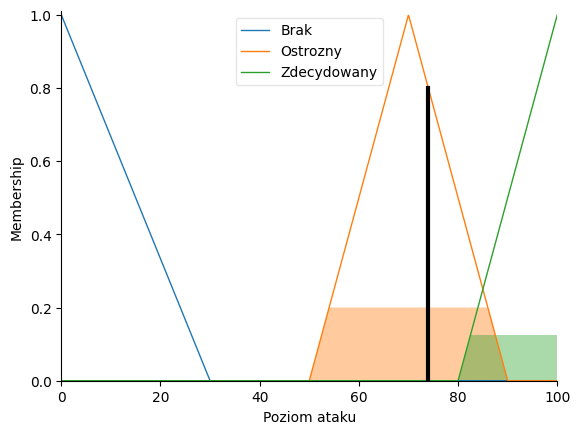

In [34]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

life = ctrl.Antecedent(np.linspace(0, 100, 1000), 'Zycie gracza')
distance = ctrl.Antecedent(np.linspace(0, 50, 1000), 'Odleglosc')

attack = ctrl.Consequent(np.linspace(0, 100, 1000), 'Poziom ataku')

life['Niskie'] = fuzz.trimf(life.universe, [0, 0, 40])
life['Srednie'] = fuzz.trimf(life.universe, [30, 50, 70])
life['Wysokie'] = fuzz.trimf(life.universe, [60, 100, 100])

distance['Mala'] = fuzz.trimf(distance.universe, [0, 0, 15])
distance['Duza'] = fuzz.trimf(distance.universe, [10, 50, 50])

attack['Brak'] = fuzz.trimf(attack.universe, [0, 0, 30])
attack['Ostrozny'] = fuzz.trimf(attack.universe, [50, 70, 90])
attack['Zdecydowany'] = fuzz.trimf(attack.universe, [80, 100, 100])

rule1 = ctrl.Rule(life['Niskie'], attack['Zdecydowany'])
rule2 = ctrl.Rule(life['Srednie'] & distance['Duza'], attack['Ostrozny'])
rule3 = ctrl.Rule(life['Srednie'] & distance['Mala'], attack['Ostrozny'])
rule4 = ctrl.Rule(life['Wysokie'] & distance['Mala'], attack['Brak'])

attack_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
attack_sim = ctrl.ControlSystemSimulation(attack_ctrl)

attack_sim.input['Zycie gracza'] = 35
attack_sim.input['Odleglosc'] = 12

attack_sim.compute()

print(f"Poziom ataku:, {attack_sim.output['Poziom ataku']:.2f}")
attack.view(sim=attack_sim)
